##### AI TECH - Akademia Innowacyjnych Zastosowań Technologii Cyfrowych. Programu Operacyjnego Polska Cyfrowa na lata 2014-2020
<hr>

## <br>
<br>
<br>
<br>
<br>
<br>
<br>
<center>
    <h1 style = "font-size:48px; font-weight:normal"><b>AI</b>-TECH</h1>
    <br>
<br>
<br>
<br>
    <h1 style = "font-size:24px; font-weight:normal">Przykład 3 DO LABORATORIUM 4</h1>
    <h1 style = "font-size:24px">z UCZENIA MASZYNOWEGO</h1>
    <h1 style = "font-size:24px">Metoda gradientu prostego, perceptron</h1>
    <h1 style = "font-size:24px">Tomasz Neumann</h1>
    <h3 style = "font-size:21px">SGDRegressor</h3>
</center>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
    </body>
    </html>

![stopka.svg](stopka.svg)

<center>
Projekt współfinansowany ze środków Unii Europejskiej w ramach Europejskiego Funduszu Rozwoju Regionalnego 
Program Operacyjny Polska Cyfrowa na lata 2014-2020,
Oś Priorytetowa nr 3 "Cyfrowe kompetencje społeczeństwa" Działanie  nr 3.2 "Innowacyjne rozwiązania na rzecz aktywizacji cyfrowej" 
Tytuł projektu:  „Akademia Innowacyjnych Zastosowań Technologii Cyfrowych (AI Tech)”
    </center>

<hr>

# 1. Przykład 3

Zastosowanie metody Stochastic Gradient Descent (SGD) do klasyfikatora liniowego lub regresora zapewnia efektywny estymator problemów związanych z klasyfikacją i regresją.

Scikit-learn API udostępnia klasę SGDRegressor do implementacji metody SGD dla problemów regresji. Regresor SGD stosuje regularyzowany model liniowy z uczeniem SGD w celu zbudowania estymatora. Są to regulatory L1, L2 lub Elastic Net dodane do funkcji strat w celu zmniejszenia parametrów modelu. Regresor SGD działa dobrze z wielkoskalowymi zbiorami danych.
Spróbujmy więc dopasowywać i przewidywać dane regresji przy użyciu klasy SGDRegressor modułu Scikit-learn. W tym celu rozpoczynamy od dołaczenia odpowiednich bibliotek


In [1]:
from sklearn.linear_model import SGDRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt 

oraz wygenerowania losowych danych wejściowych przy użyciu klasy <i>make_regression()</i> tak, aby zbiór danych zawierał 10000 próbek o 30 cechach.

In [2]:
x, y = make_regression(n_samples=1000, n_features=30, noise=21)

W celu poprawienia dokładności modelu, dane x i y zostaną przeskalowane, a następnie podzielone na zbiór zbiór treningowy i testowy, gdzie zbiór testowy będzie stanowił 15% wszystkich próbek.

In [3]:
x = scale(x)
y = scale(y)
xtrain, xtest, ytrain, ytest=train_test_split(x, y, test_size=0.15)

Następnie można zbudować model regresora za pomocą klasy SGDRegressor

In [4]:
sgdr = SGDRegressor()
print(sgdr)

SGDRegressor()


po czym można przystapić do wytrenowania i sprawdzania jakości treningu jak i wyuczonych wag.

In [5]:
sgdr.fit(xtrain, ytrain)
score = sgdr.score(xtrain, ytrain)
print("R-squared:", score)
#wyświetlenie macierzy wag
sklearn_w=sgdr.coef_
print("Macierz wag: ", sklearn_w)

R-squared: 0.9878199524478806
Macierz wag:  [ 1.34360241e-01  2.66228760e-01 -6.69646240e-03 -2.29412004e-03
  1.31935479e-01  7.66318284e-03  4.33290747e-03  4.20781931e-03
  1.82876017e-03  4.50132110e-03  2.51867147e-03  6.65725812e-04
  2.84150815e-01  3.89246433e-01 -5.20414399e-03 -2.30755405e-03
  2.76783809e-03  1.88016744e-01  4.15475962e-01 -9.00336751e-03
 -1.81482283e-04 -1.77615630e-03 -3.37101811e-03  3.28644202e-01
  8.40571906e-03  4.15425886e-01  2.66454641e-03  3.80824701e-01
  2.23485656e-03  1.94770606e-03]


Można także w tym przypadku zastosować walidację krzyżową i sprawdzić dokładność wytrenowanego modelu.

In [6]:
cv_score = cross_val_score(sgdr, x, y, cv = 10)
print("CV mean score: ", cv_score.mean())

CV mean score:  0.9872545262447187


Aktualnie, można dokonać predykcji na wytrenowanym modelu oraz sprawdzić dokładność tych prognoz za pomocą metryki MSE i RMSE.

In [7]:
ypred = sgdr.predict(xtest)

mse = mean_squared_error(ytest, ypred)
print("MSE: ", mse)
print("RMSE: ", mse*(1/2.0)) 

MSE:  0.009537972165175474
RMSE:  0.004768986082587737


Ostatecznie można zwizualizować dane oryginalne oraz te uzyskane z predykcji.

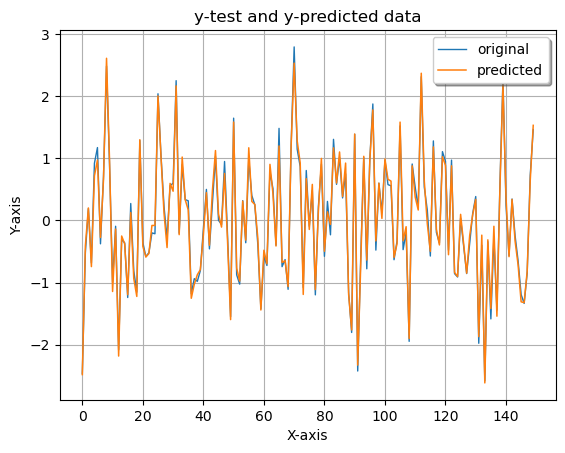

In [8]:
x_ax = range(len(ytest))
plt.plot(x_ax, ytest, linewidth=1, label="original")
plt.plot(x_ax, ypred, linewidth=1.1, label="predicted")
plt.title("y-test and y-predicted data")
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend(loc='best',fancybox=True, shadow=True)
plt.grid(True)
plt.show()

# Zadania do wykonania

<p><b>Zadanie 1</b></p>
Przeprowadź eksperymenty dla SGDRegressor dla zbioru danych zaczytanych z load_diabetes (<a>https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html#sklearn.datasets.load_diabetes</a>). Zbiór zawiera dane 442 pacjentów, z czego w pierwszych 10 jest informacja zmiennoprzecinkowa o (w kolejności) wieku, płci wskaźniku masy ciała, średnie cisnienie krwi i sześć pomiarów surowicy krwi, a w ostatniej kolumnie znajduje się ilościowa progresja choroby rok po wizycie początkowej.


In [9]:
# Task 1 - SGDRegressor on load_diabetes
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()

rows = []
for eta0 in [0.0001, 0.001, 0.01, 0.1]:
    model = SGDRegressor(
        loss="squared_error",
        penalty="l2",
        alpha=0.0001,
        learning_rate="constant",
        eta0=eta0,
        max_iter=5000,
        random_state=42,
        tol=1e-4,
    )
    model.fit(X_train_scaled, y_train_scaled)
    y_pred_scaled = model.predict(X_test_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    mse = mean_squared_error(y_test, y_pred)
    rows.append({
        "eta0": eta0,
        "iterations": model.n_iter_,
        "R2": r2_score(y_test, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
    })

results = pd.DataFrame(rows)
print(results.to_string(index=False, float_format=lambda x: f"{x:.6f}"))


    eta0  iterations        R2          MSE       RMSE
0.000100          66  0.426440  3133.244021  55.975388
0.001000          16  0.420953  3163.220452  56.242515
0.010000          16  0.406415  3242.640083  56.944184
0.100000           9 -1.208685 12065.608670 109.843565


<p><b>Wnioski do zadania 1</b></p>

Najlepszy wynik w tym eksperymencie uzyskał `eta0=0.0001`: `R2=0.426`, `MSE=3133.244` i `RMSE=55.975`.

Dla `eta0=0.001` wynik był bardzo podobny, ale nieco słabszy (`R2=0.420`, `RMSE=56.242`).

Zwiększenie `eta0` do `0.01` lekko pogorszyło wynik (`R2=0.406`, `RMSE=56.944`)

`eta0=0.1` dało już bardzo słaby model (`R2=-1.208`, `RMSE=109.843`).

Na podstawie tych wyników dla tego podziału danych najlepszym wyborem z testowanych wartości jest `eta0=0.0001`.

W tym ćwiczeniu wartości R2 około 0.42 wskazują, że liniowy SGDRegressor uchwycił część zależności w danych diabetes, ale predykcja nadal ma duży błąd bezwzględny w skali problemu. To jest realistyczny wynik dla prostego modelu liniowego na tym zbiorze. Natomiast nie jest to idealne dopasowanie.
